# Feature Bivariate Analysis

## Objective

Analyze the relationship between each feature and the target variable (`y`) in order to identify potentially predictive patterns.

This notebook focuses on:

- categorical features vs target
- numerical features vs target
- conversion rate analysis
- early modeling insights


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [4]:
df = pd.read_csv("../data/raw/bank-full.csv", sep=";")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [14]:
# Identificar columnas numéricas
num_cols = df.select_dtypes(include="number").columns.tolist()

# Identificar columnas categóricas
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

# Eliminar la variable objetivo si está en categóricas
target = "y"
cat_cols = [col for col in cat_cols if col != target]

print("Columnas numéricas:", num_cols)
print("Columnas categóricas:", cat_cols)


Columnas numéricas: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Columnas categóricas: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [6]:
def plot_conversion_rate(data, feature, target="y"):
    conv = (
        data.groupby(feature)[target]
        .apply(lambda x: (x == "yes").mean())
        .sort_values(ascending=False)
    )
    
    conv.plot(kind="bar")
    plt.title(f"Conversion Rate by {feature}")
    plt.ylabel("Proportion of 'yes'")
    plt.tight_layout()
    plt.show()
    
    return conv

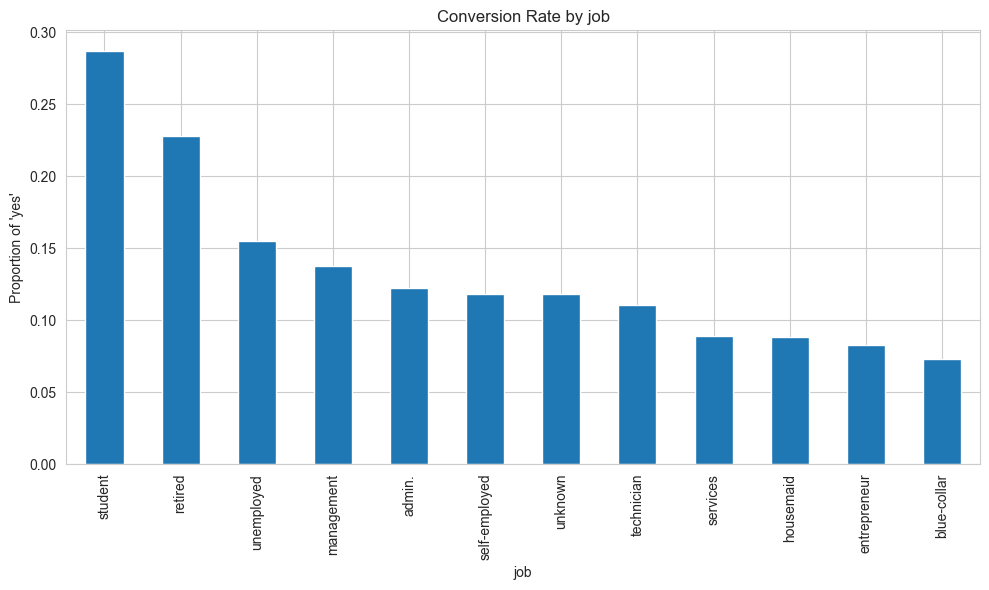

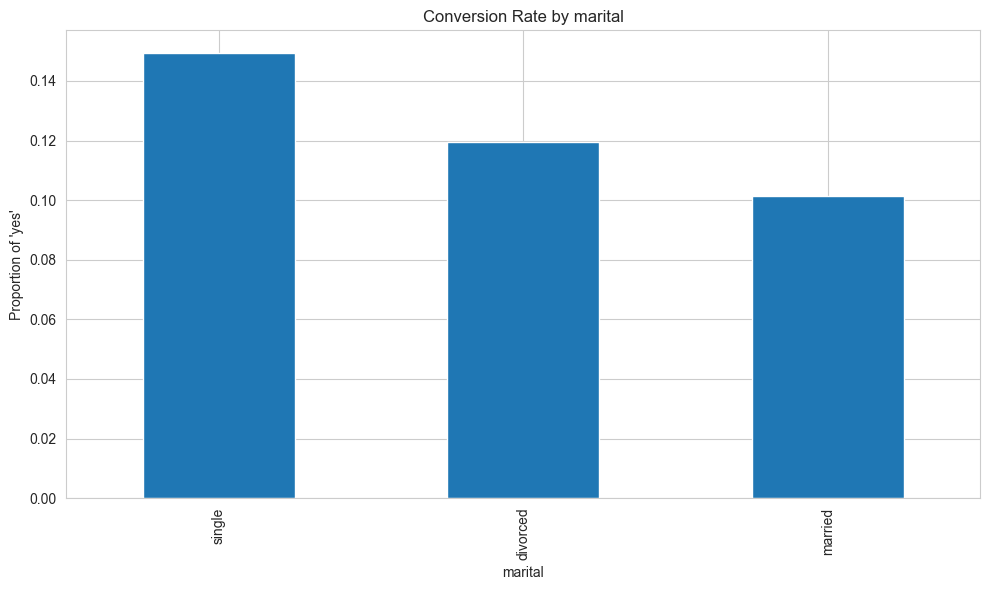

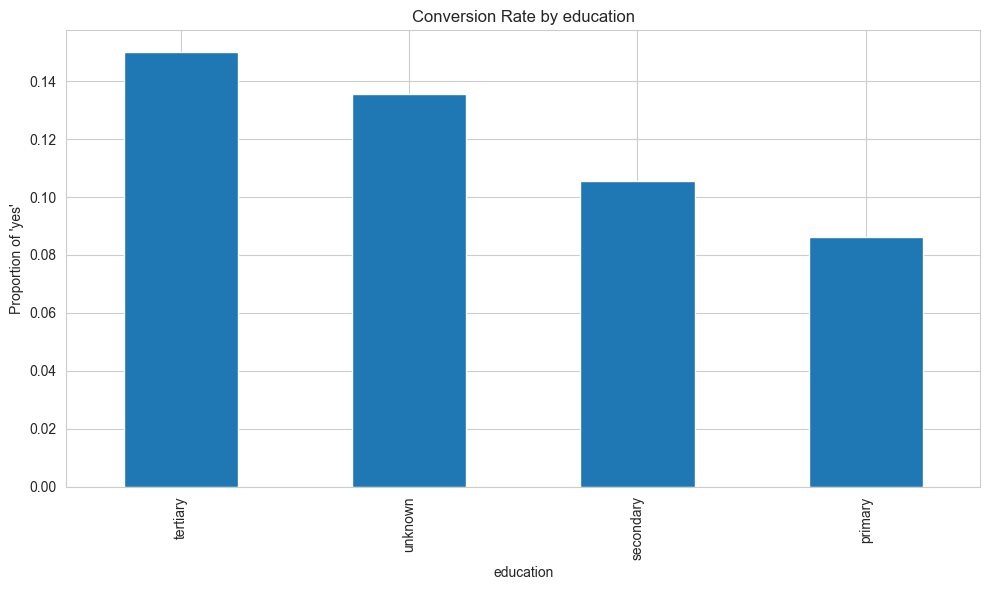

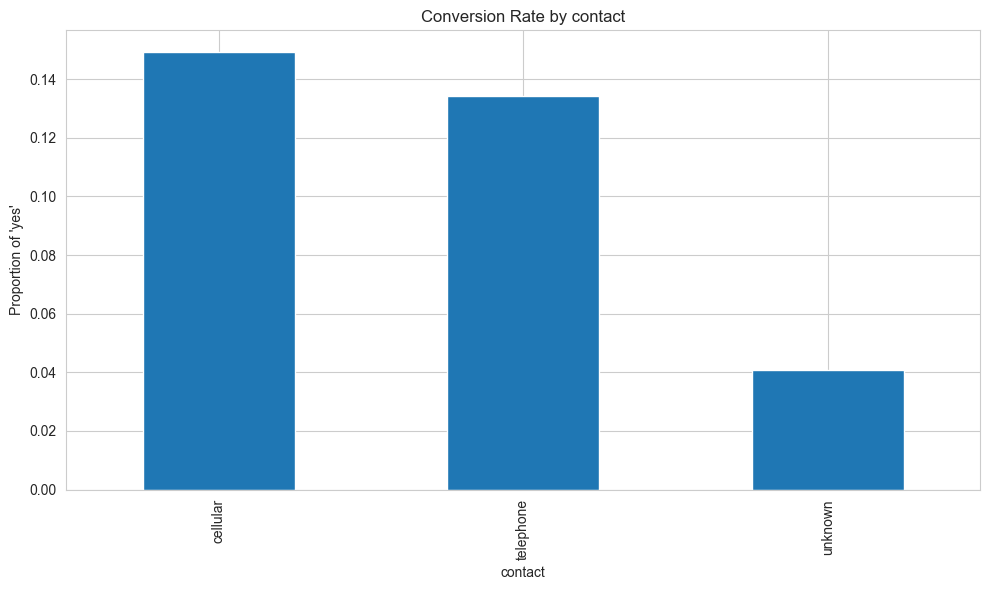

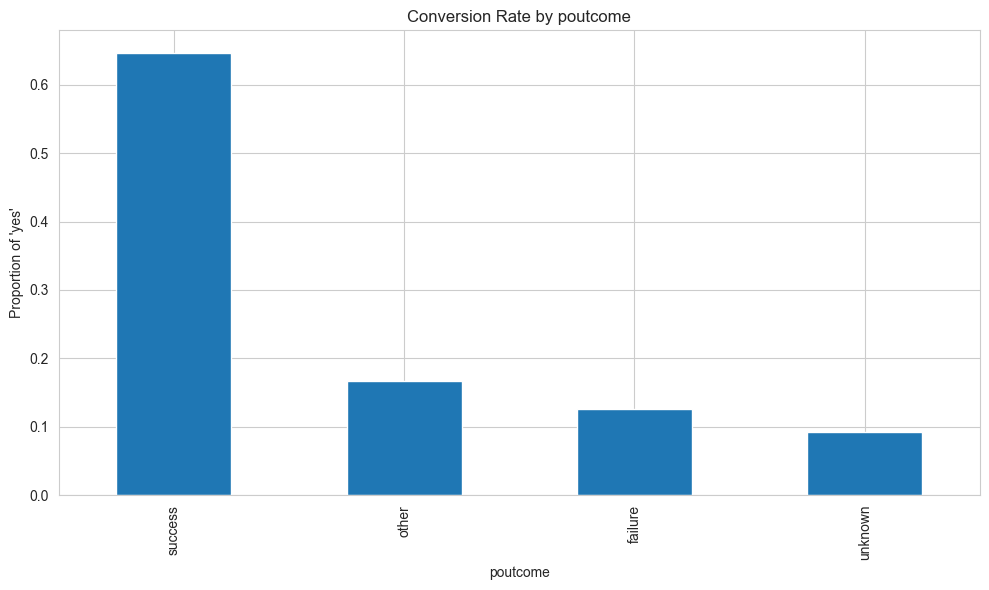

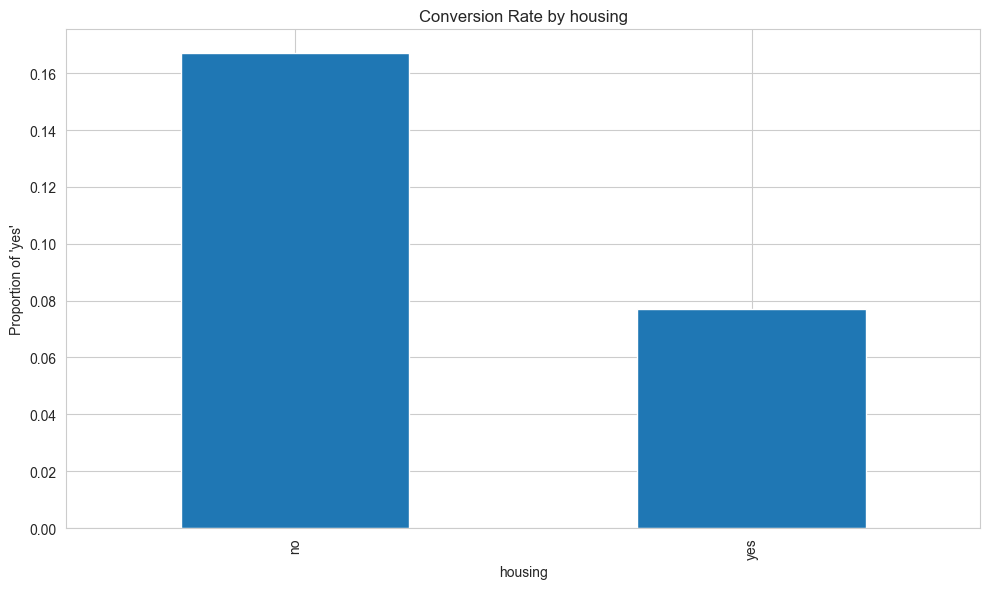

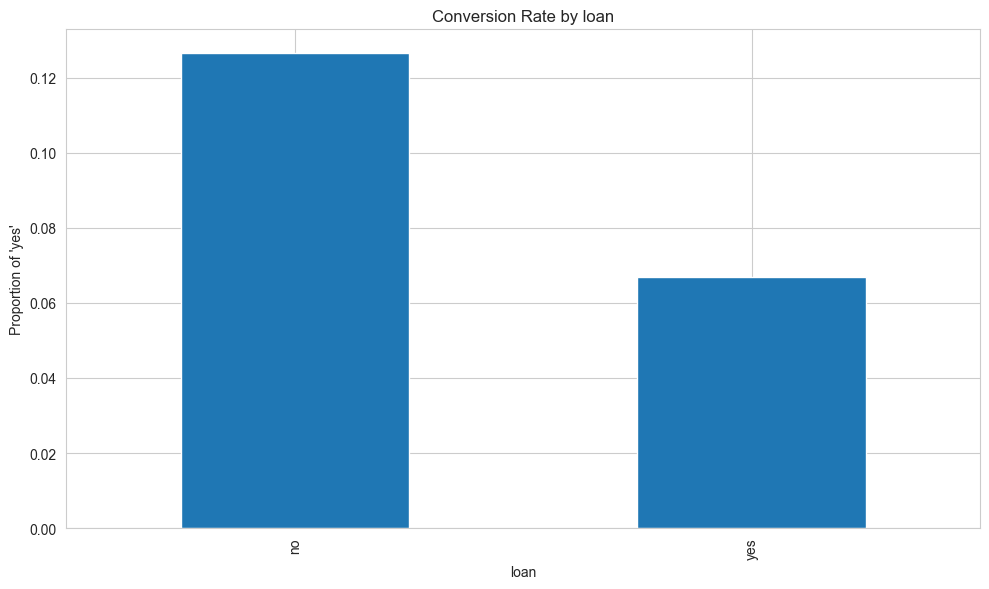

loan
no     0.126557
yes    0.066814
Name: y, dtype: float64

In [7]:
plot_conversion_rate(df, "job")
plot_conversion_rate(df, "marital")
plot_conversion_rate(df, "education")
plot_conversion_rate(df, "contact")
plot_conversion_rate(df, "poutcome")
plot_conversion_rate(df, "housing")
plot_conversion_rate(df, "loan")

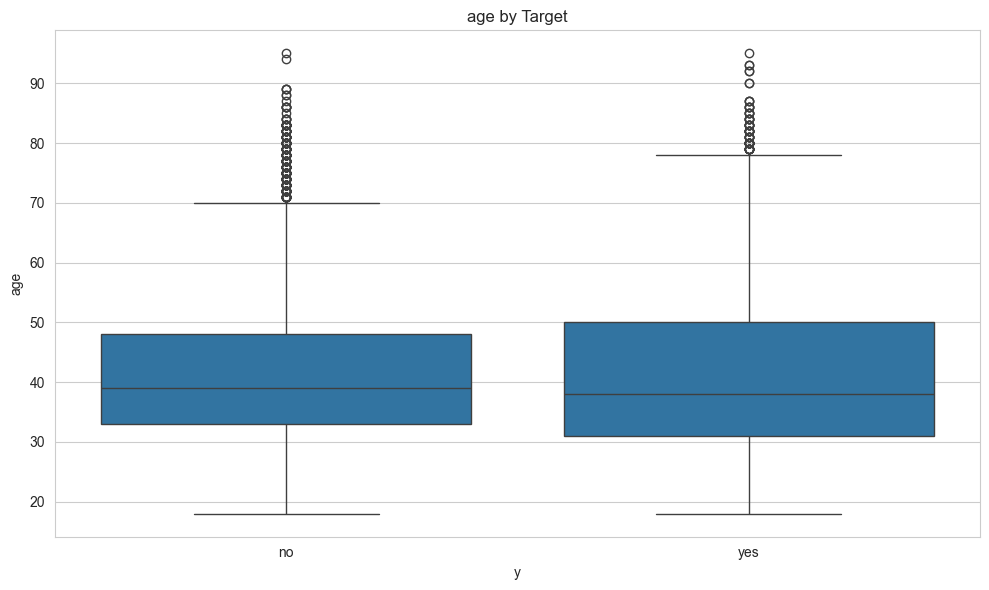

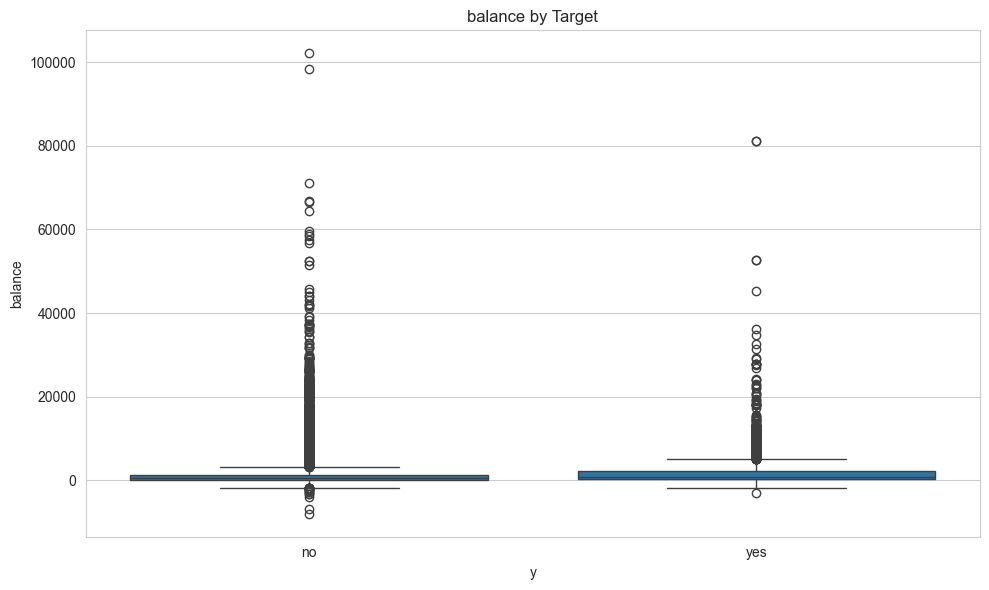

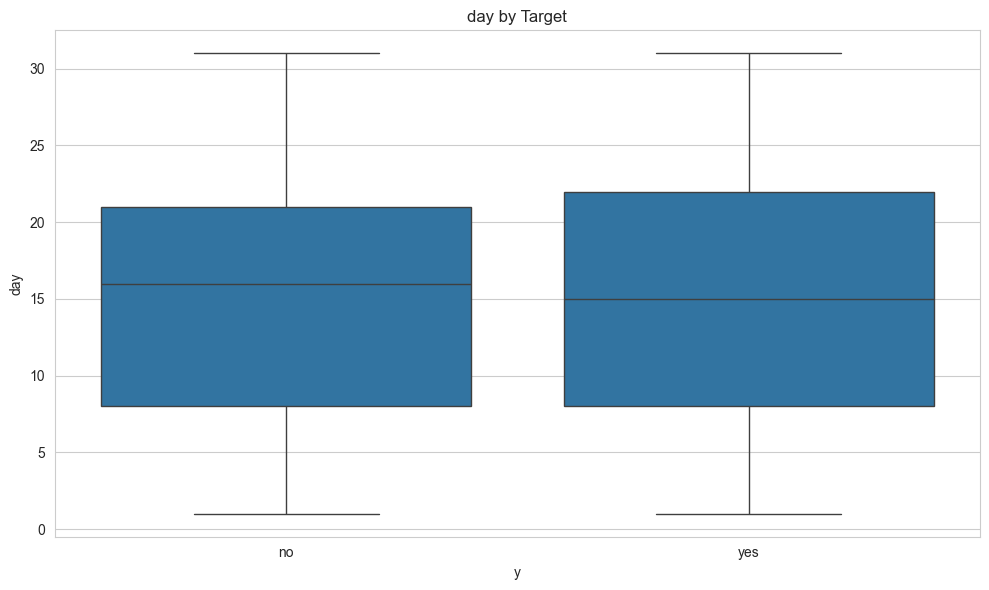

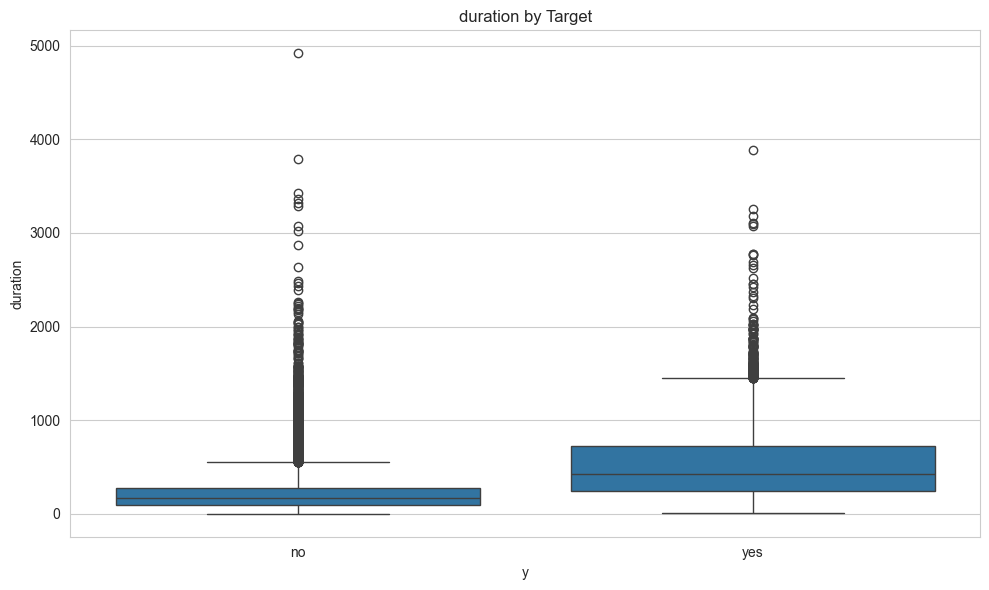

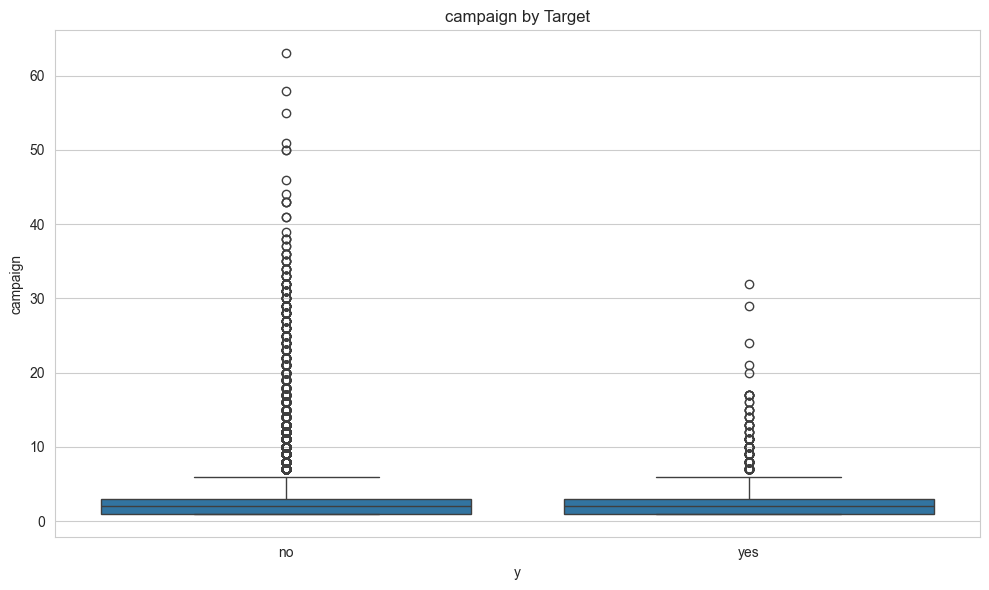

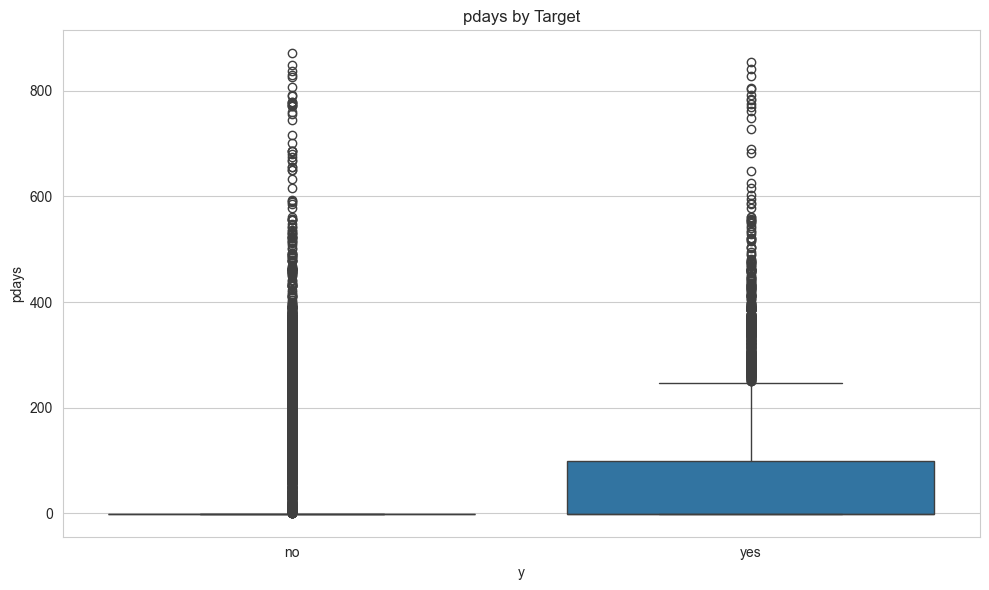

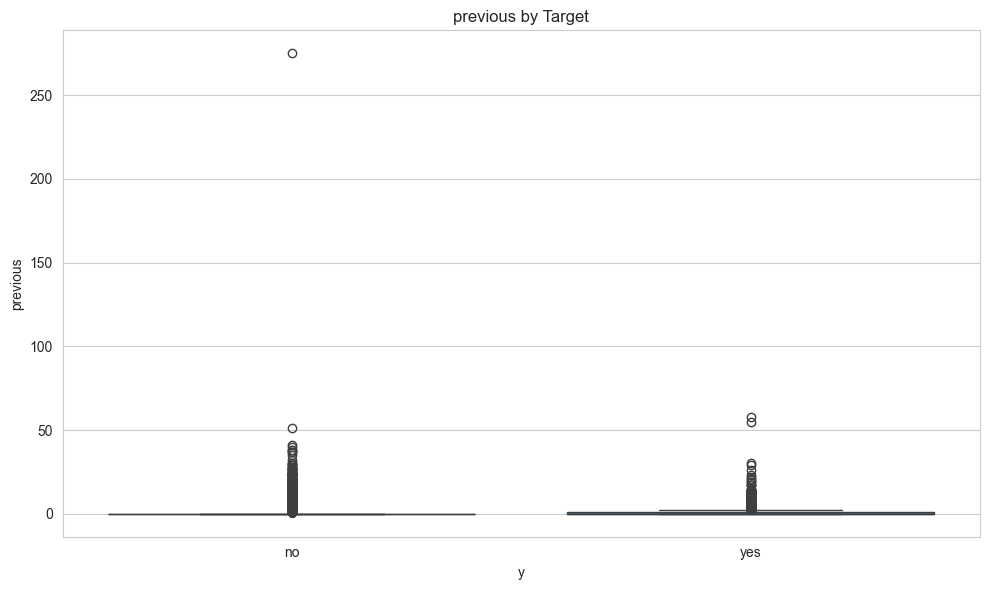

In [8]:
for col in num_cols:
    sns.boxplot(data=df, x="y", y=col)
    plt.title(f"{col} by Target")
    plt.tight_layout()
    plt.show()

In [9]:
df.groupby("y")[num_cols].median().T

y,no,yes
age,39.0,38.0
balance,417.0,733.0
day,16.0,15.0
duration,164.0,426.0
campaign,2.0,2.0
pdays,-1.0,-1.0
previous,0.0,0.0


In [10]:
df.groupby("y")[num_cols].mean().T

y,no,yes
age,40.838986,41.670070
balance,1303.714969,1804.267915
day,15.892290,15.158253
duration,221.182806,537.294574
campaign,2.846350,2.141047
pdays,36.421372,68.702968
previous,0.502154,1.170354


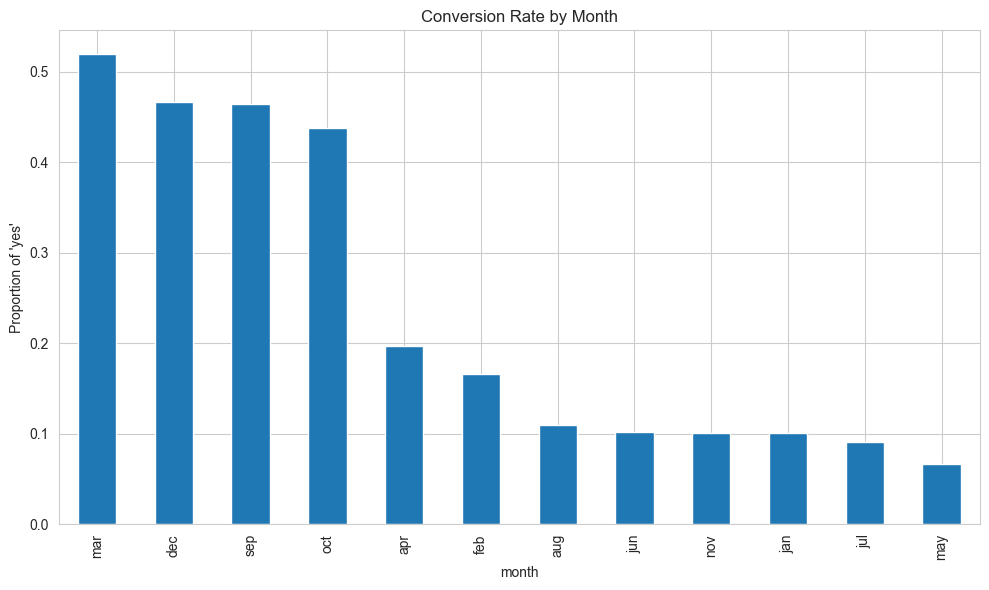

In [11]:
month_conv = (
    df.groupby("month")["y"]
    .apply(lambda x: (x == "yes").mean())
    .sort_values(ascending=False)
)

month_conv
month_conv.plot(kind="bar")
plt.title("Conversion Rate by Month")
plt.ylabel("Proportion of 'yes'")
plt.tight_layout()
plt.show()

In [12]:
contact_conv = (
    df.groupby("contact")["y"]
    .apply(lambda x: (x == "yes").mean())
    .sort_values(ascending=False)
)

contact_conv

contact
cellular     0.149189
telephone    0.134205
unknown      0.040707
Name: y, dtype: float64

## Key Findings

- `poutcome` appears highly informative, even when many records are labeled as `unknown`.
- `contact` shows a strong difference in conversion rates across categories.
- `duration` strongly separates the classes, but it introduces leakage and will not be used in the production model.
- Some numerical features such as `campaign` and `previous` may contain predictive signal, although their distributions are highly skewed.
- Categorical features such as `job`, `marital`, and `education` show moderate differences in conversion rates and should be retained for modeling.

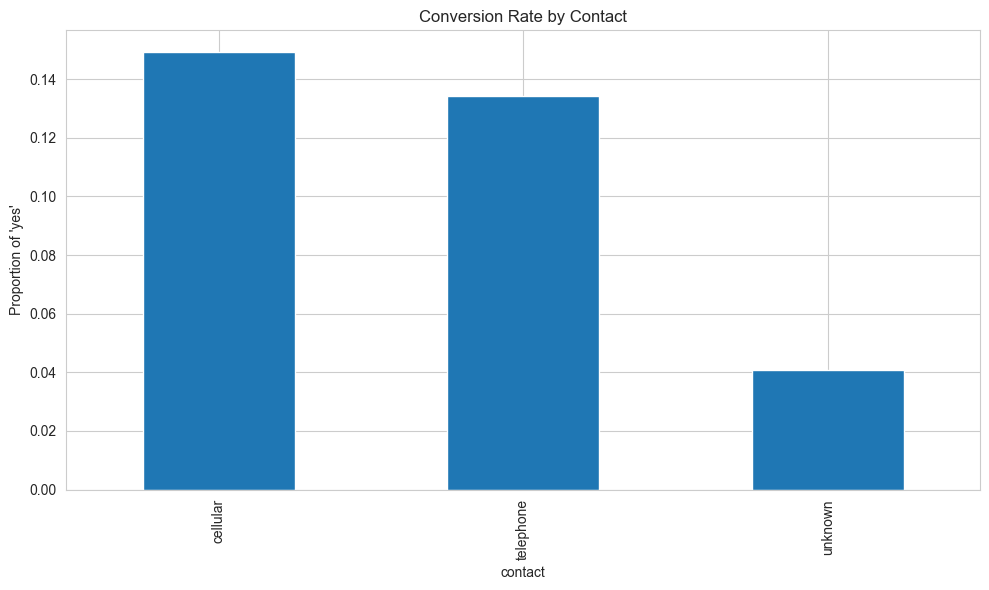

In [13]:
conv = (
    df.groupby("contact")["y"]
    .apply(lambda x: (x == "yes").mean())
    .sort_values(ascending=False)
)

conv.plot(kind="bar")
plt.title("Conversion Rate by Contact")
plt.ylabel("Proportion of 'yes'")
plt.tight_layout()
plt.savefig("../reports/figures/conversion_rate_contact.png")
plt.show()